In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import string
%matplotlib inline


In [2]:
words = open('names.txt', 'r').read().splitlines()
# words = open('input.txt', 'r').read().lower().splitlines()
# words.remove("")
# table = str.maketrans('', '', string.punctuation)
# words = [s.translate(table) for s in words]
words[:3]

['emma', 'olivia', 'ava']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(f"{vocab_size=}, {itos=}")

vocab_size=27, itos={1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
block_size = 8 
def build_datset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f"{X.shape=}, {Y.shape=}")
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_datset(words[:n1])
Xdev, Ydev = build_datset(words[n1:n2])
Xte, Yte = build_datset(words[n2:])

X.shape=torch.Size([182625, 8]), Y.shape=torch.Size([182625])
X.shape=torch.Size([22655, 8]), Y.shape=torch.Size([22655])
X.shape=torch.Size([22866, 8]), Y.shape=torch.Size([22866])


In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.randn(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum = 0.01):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3 :
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)# , unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x-xmean)/ torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
      self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self,x):
        B,T,C = x.shape
        x = x.view(B, T//self.n, C*self.n )
        if x.shape[1] == 1:
            x = x.squeeze(1)
        
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    


In [39]:
torch.manual_seed(42)

In [ ]:
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

# C = torch.randn((vocab_size, n_embd))
model = Sequential( [
    Embedding(vocab_size, n_embd ),
    FlattenConsecutive(2),Linear(n_embd * 2, n_hidden,  bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden,  bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden,  bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,  vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

# parameters = [p for layer in layers for p in layer.parameters()]
parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

76579


In [41]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  1, 13,  9,  9],
        [ 0,  0,  0,  4,  5,  1, 22, 15],
        [ 0,  0, 10,  1, 19,  8, 21,  1],
        [ 0,  0,  0,  0,  0,  0,  1, 14]])

In [49]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 24)
FlattenConsecutive : (32, 4, 48)
Linear : (32, 4, 128)
BatchNorm1d : (32, 4, 128)
Tanh : (32, 4, 128)
FlattenConsecutive : (32, 2, 256)
Linear : (32, 2, 128)
BatchNorm1d : (32, 2, 128)
Tanh : (32, 2, 128)
FlattenConsecutive : (32, 256)
Linear : (32, 128)
BatchNorm1d : (32, 128)
Tanh : (32, 128)
Linear : (32, 27)


In [48]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix] , Ytr[ix]

    # forward pass
    # emb = C[Xb]
    # x= emb.view(emb.shape[0], -1)
    # x = Xb
    # for layer in layers:
    #     x = layer(x)
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())
    # break

      0/ 200000: 3.9689
  10000/ 200000: 2.0594
  20000/ 200000: 1.8710
  30000/ 200000: 2.1884
  40000/ 200000: 2.0625
  50000/ 200000: 2.2141
  60000/ 200000: 1.9610
  70000/ 200000: 2.1949
  80000/ 200000: 2.1377
  90000/ 200000: 2.0717
 100000/ 200000: 2.3079
 110000/ 200000: 1.7485
 120000/ 200000: 1.6197
 130000/ 200000: 2.0723
 140000/ 200000: 2.0330
 150000/ 200000: 1.5902
 160000/ 200000: 1.7611
 170000/ 200000: 1.7570
 180000/ 200000: 2.0574
 190000/ 200000: 1.9480


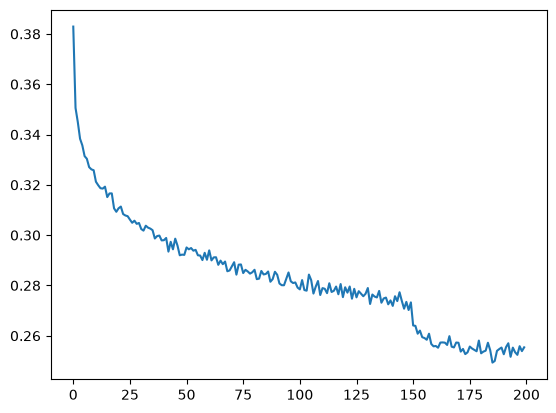

In [50]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [51]:
for layer in model.layers:
    layer.training = False

In [52]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    # emb = C[x] # (N, block_size, n_embd)
    # x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    # for layer in layers:
    #     x = layer(x)
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7680753469467163
val 1.9883100986480713


In [56]:
for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        # # emb = C[torch.tensor([context])]
        # x = emb.view(emb.shape[0], -1)
        # for layer in layers:
        #     x = layer(x)

        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix==0:
            break

    print(''.join(itos[i] for i in out))


johnne.
emmary.
jalayah.
lennin.
vivan.
maisani.
rithika.
finnoni.
gerald.
anneng.
